# `EDA on Insurance Claim Dataset:`

## `Notebook Overview:`

In this notebook, we will take a closer look at Insurance Claims and figure out some facts about how conditions such as blood pressure, BMI, diabetes, smoking, age, and gender impact the claim value.

We will touch the topics through exploratory data analysis (EDA) using scatter plots, pie charts, histograms etc.

In [2]:
# importing necessary libraries
import numpy as np    # for linear algebra
import pandas as pd   # for reading data files
import matplotlib.pyplot as plt  # for making graphs
%matplotlib inline
import seaborn as sns  # another library for making graphs 

In [3]:
# reading the csv file
df_ins = pd.read_csv('insurance_data.csv')

## `Data Processing and Data Preparation:`

In [4]:
# checking the dataset content
df_ins.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [5]:
# checking the rows and cols of the dataset
rows = df_ins.shape[0]
cols = df_ins.shape[1]
print(f'The insurance claim dataset contains {rows} rows and {cols} cols')


The insurance claim dataset contains 1340 rows and 11 cols


In [6]:
# data types + non-null counts for every column
df_ins.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   str    
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   str    
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   str    
 9   region         1337 non-null   str    
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 115.3 KB


In [7]:
# finding which cols have null values
df_ins.isna().sum()

index            0
PatientID        0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

> This shows the our age col and region col have null values we need to handle them safely.

In [8]:
df = df_ins.copy()

# age (numeric, low skew) → median fill
df['age'] = df['age'].fillna(df['age'].median())

# region (categorical) → mode fill
df['region'] = df['region'].fillna(df['region'].mode()[0])

df.isna().sum()

index            0
PatientID        0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [9]:
# getting a deeper look in the dataset
df.describe().round(0)

,index,PatientID,age,bmi,bloodpressure,children,claim
count,1340.0,1340.0,1340.0,1340.0,1340.0,1340.0,1340.0
mean,670.0,670.0,38.0,31.0,94.0,1.0,13253.0
std,387.0,387.0,11.0,6.0,11.0,1.0,12110.0
min,0.0,1.0,18.0,16.0,80.0,0.0,1122.0
25%,335.0,336.0,29.0,26.0,86.0,0.0,4720.0
50%,670.0,670.0,38.0,30.0,92.0,1.0,9370.0
75%,1004.0,1005.0,47.0,35.0,99.0,2.0,16604.0
max,1339.0,1340.0,60.0,53.0,140.0,5.0,63770.0


In [10]:
# checking for the categorical col and there values in dataset
for col in df.columns:
    if df[col].dtype == 'str':
        print(col)
        print(df[col].unique())
        print()

gender
<StringArray>
['male', 'female']
Length: 2, dtype: str

diabetic
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

smoker
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

region
<StringArray>
['southeast', 'northwest', 'southwest', 'northeast']
Length: 4, dtype: str



In [11]:
# replacing the diabetic and smoker col appropriately using replace for better understanding
df['diabetic'] = df['diabetic'].replace({'Yes': 'diabetic', 'No': 'non-diabetic'})
df['smoker'] = df['smoker'].replace({'Yes': 'smoker', 'No': 'non-smoker'})

In [12]:
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,diabetic,0,non-smoker,southeast,1121.87
1,1,2,24.0,male,30.1,87,non-diabetic,0,non-smoker,southeast,1131.51
2,2,3,38.0,male,33.3,82,diabetic,0,non-smoker,southeast,1135.94
3,3,4,38.0,male,33.7,80,non-diabetic,0,non-smoker,northwest,1136.40
4,4,5,38.0,male,34.1,100,non-diabetic,0,non-smoker,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,diabetic,0,smoker,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,non-diabetic,1,smoker,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,diabetic,3,smoker,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,non-diabetic,0,smoker,southeast,62592.87


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1340 non-null   float64
 3   gender         1340 non-null   str    
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   str    
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   str    
 9   region         1340 non-null   str    
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 115.3 KB


> Every null value is maintained safely and we have a breif overview about the data we are working on.

## `Exploratory Data Analysis (EDA):`

**`Numerical Columns:`**

- age
- bmi
- bloodpressure
- children
- claim

**`Categorical Columns:`**

- gender
- diabetic
- smoker
- region

### `Univariate Analysis:`

#### `Numerical Columns:`

**`1. age:`**

In [14]:
df['age'].describe()

count    1340.000000
mean       38.078358
std        11.082176
min        18.000000
25%        29.000000
50%        38.000000
75%        47.000000
max        60.000000
Name: age, dtype: float64

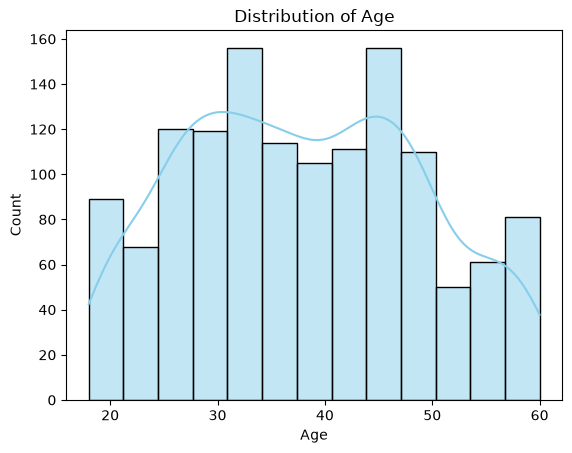

In [15]:
sns.histplot(data=df, x='age', kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

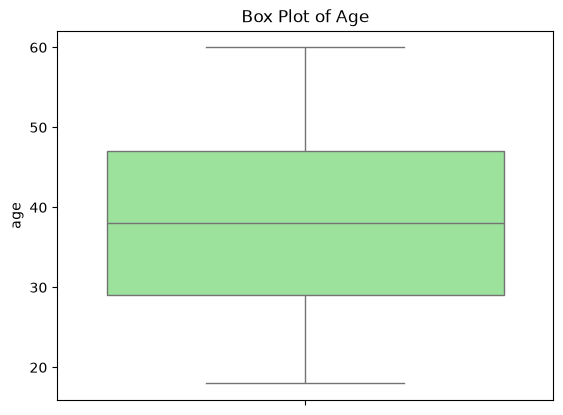

In [16]:
sns.boxplot(data=df, y='age', color='lightgreen')

plt.title('Box Plot of Age')

plt.show()

In [17]:
df['age'].skew()

np.float64(0.11390294679791582)

**Conclusion:**
- The kde shows 2 peaks
- Age is almost rougly symmetrical
- Boxplot shows there is no outlier in the age col

**`2. bmi:`**

In [18]:
df['bmi'].describe()

count    1340.000000
mean       30.668955
std         6.106735
min        16.000000
25%        26.275000
50%        30.400000
75%        34.700000
max        53.100000
Name: bmi, dtype: float64

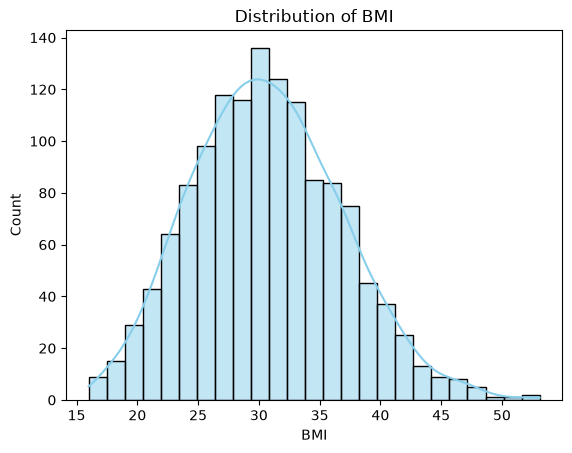

In [19]:
sns.histplot(data=df, x='bmi', kde=True, color='skyblue')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

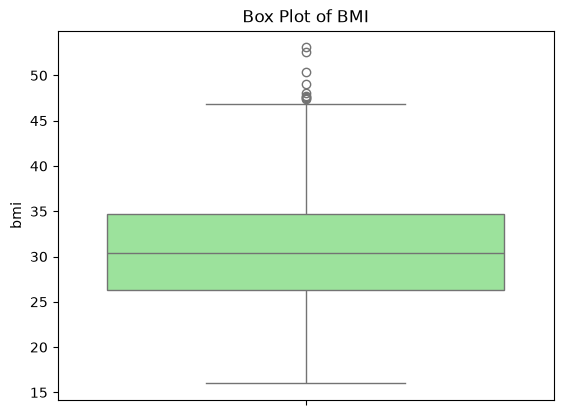

In [20]:
sns.boxplot(data=df, y='bmi', color='lightgreen')

plt.title('Box Plot of BMI')

plt.show()

In [21]:
df[df['bmi'] > 47]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
9,9,10,30.0,male,53.1,97,non-diabetic,0,non-smoker,northwest,1163.46
141,141,142,46.0,male,50.4,89,diabetic,1,non-smoker,southeast,2438.06
579,579,580,25.0,male,47.5,84,diabetic,1,non-smoker,southeast,8083.92
675,675,676,49.0,female,48.1,81,diabetic,2,non-smoker,northeast,9432.93
696,696,697,49.0,male,47.7,88,non-diabetic,1,non-smoker,southeast,9748.91
802,802,803,42.0,male,49.1,109,diabetic,0,non-smoker,southeast,11381.33
1299,1299,1300,50.0,male,52.6,110,non-diabetic,1,smoker,southeast,44501.40
1306,1306,1307,43.0,female,47.6,112,diabetic,2,smoker,southwest,46113.51
1339,1339,1340,30.0,female,47.4,101,non-diabetic,0,smoker,southeast,63770.43


In [22]:
df['bmi'].skew()

np.float64(0.28597245020808587)

**Conclusion:**
- The bmi kde shows that it is almost normal but there is some stretch in the right side 
- There are outliers in the bmi col as shown in the boxplot these are the people who are obese mostly those people whose bmi is greater then 47. This can be used further to find if it effect the insurance claim when doing bi-variate anaylsis.
- There are 9 patients who will be counted as outliers. 

**`3. bloodpressure:`**

In [23]:
df['bloodpressure'].describe()

count    1340.000000
mean       94.157463
std        11.434712
min        80.000000
25%        86.000000
50%        92.000000
75%        99.000000
max       140.000000
Name: bloodpressure, dtype: float64

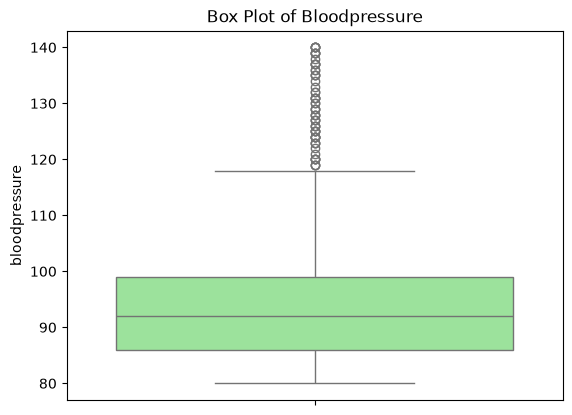

In [24]:
sns.boxplot(data=df, y='bloodpressure', color='lightgreen')

plt.title('Box Plot of Bloodpressure')

plt.show()

In [25]:
df[df['bloodpressure'] > 118.5]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1147,1147,1148,29.0,female,32.7,128,diabetic,2,non-smoker,northwest,26018.95
1150,1150,1151,55.0,female,27.1,135,non-diabetic,1,non-smoker,southwest,26140.36
1152,1152,1153,38.0,female,35.9,128,non-diabetic,1,non-smoker,northeast,26392.26
1153,1153,1154,43.0,male,36.8,126,non-diabetic,2,non-smoker,northwest,26467.10
1154,1154,1155,31.0,male,23.8,126,diabetic,0,smoker,southeast,26926.51
...,...,...,...,...,...,...,...,...,...,...,...
1325,1325,1326,52.0,female,36.4,133,diabetic,1,smoker,northeast,48517.56
1332,1332,1333,26.0,male,37.0,120,non-diabetic,2,smoker,southeast,49577.66
1333,1333,1334,44.0,male,36.4,127,non-diabetic,1,smoker,southwest,51194.56
1334,1334,1335,43.0,male,32.8,125,non-diabetic,0,smoker,southwest,52590.83


In [26]:
df['bloodpressure'].skew()

np.float64(1.4835342102293079)

**Conclusions:**
- The kde plot shows that bloodpressure is strongly right skewed.
- The boxplot represents the data contains outliers. This show there are some peoples with high bp any bp value above 118.5 is outlier. There are 62 patients rougly that are forming outlier cluster

**`4. children:`**

In [27]:
df['children'].describe()

count    1340.000000
mean        1.093284
std         1.205334
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

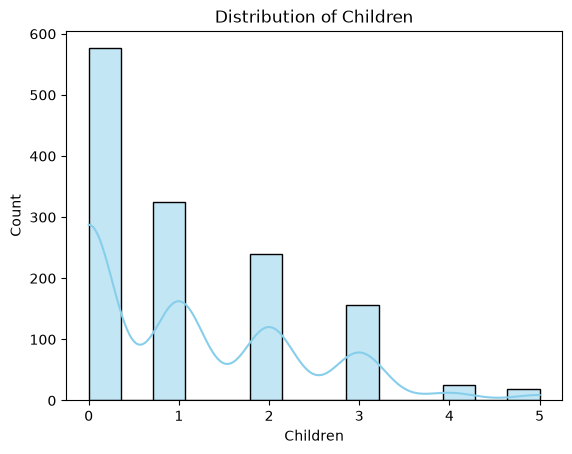

In [28]:
sns.histplot(data=df, x='children', kde=True, color='skyblue')
plt.title('Distribution of Children')
plt.xlabel('Children')
plt.ylabel('Count')
plt.show()

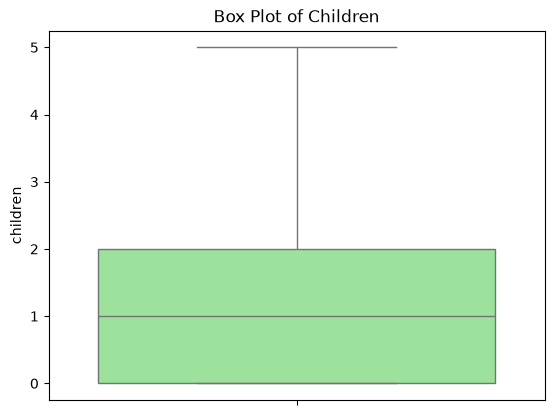

In [29]:
sns.boxplot(data=df, y='children', color='lightgreen')

plt.title('Box Plot of Children')

plt.show()

In [30]:
df['children'].skew()

np.float64(0.9402991133470963)

**Conclusion:**
- The histogram shows a discrete pattern rather then smooth curve. The data is right skewed most patients have 0-2 childerns very few have 4-5.
- The boxplot shows there is no outlier in childern data.

**`5. claim:`**

In [31]:
df['claim'].describe()

count     1340.000000
mean     13252.745642
std      12109.609288
min       1121.870000
25%       4719.685000
50%       9369.615000
75%      16604.305000
max      63770.430000
Name: claim, dtype: float64

iqr = 16604.305 - 4719.685 = 11884.62
lb = 
ub = 

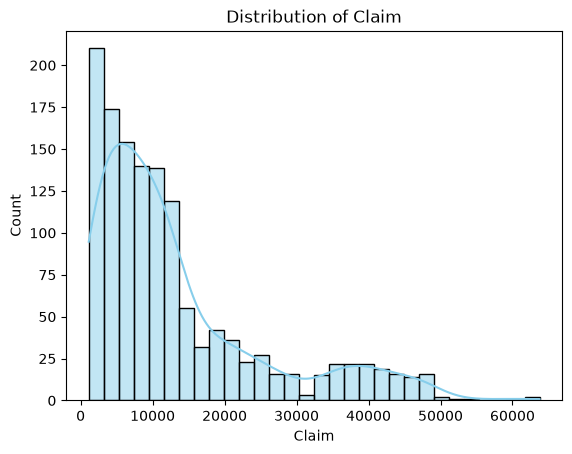

In [32]:
sns.histplot(data=df, x='claim', kde=True, color='skyblue')
plt.title('Distribution of Claim')
plt.xlabel('Claim')
plt.ylabel('Count')
plt.show()

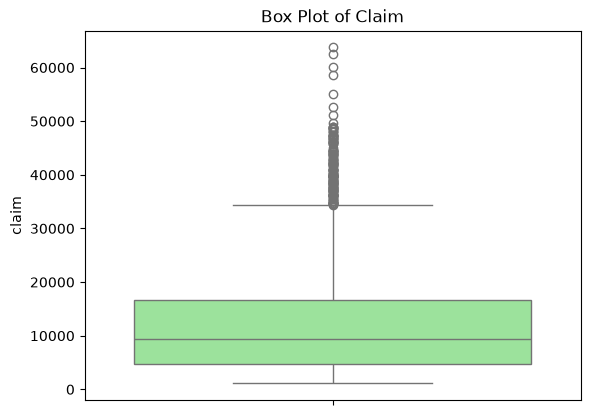

In [33]:
sns.boxplot(data=df, y='claim', color='lightgreen')

plt.title('Box Plot of Claim')

plt.show()

In [34]:
df[df['claim'] > 34431.235]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1199,1199,1200,30.0,female,33.1,93,diabetic,0,smoker,southeast,34439.86
1200,1200,1201,40.0,male,32.7,98,non-diabetic,0,smoker,southwest,34472.84
1201,1201,1202,45.0,male,33.5,81,non-diabetic,0,smoker,northeast,34617.84
1202,1202,1203,32.0,male,31.7,125,non-diabetic,0,smoker,southeast,34672.15
1203,1203,1204,26.0,male,34.8,94,diabetic,0,smoker,southwest,34779.62
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,diabetic,0,smoker,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,non-diabetic,1,smoker,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,diabetic,3,smoker,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,non-diabetic,0,smoker,southeast,62592.87


In [35]:
df['claim'].skew()

np.float64(1.5167468509489237)

**Conclusions:**
- Claim is heavily right skewed with mean that is well above median indicating a subgroup of high cost outliers above ~34,431.

### `Categorical Columns:`

**`1. gender:`**

In [36]:
df['gender'].value_counts()

gender
male      678
female    662
Name: count, dtype: int64

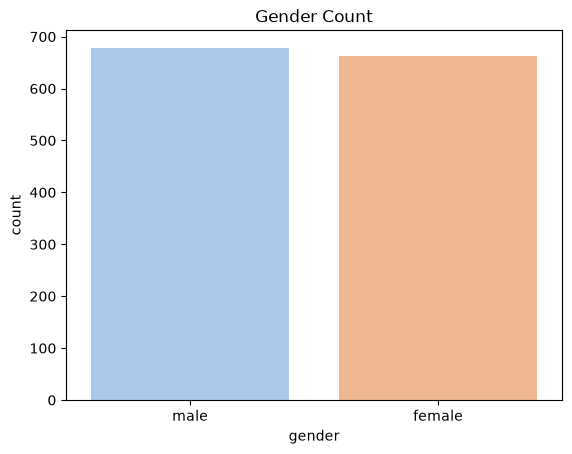

In [37]:
sns.countplot(data=df, x='gender', hue='gender', palette='pastel')
plt.title('Gender Count')
plt.show()

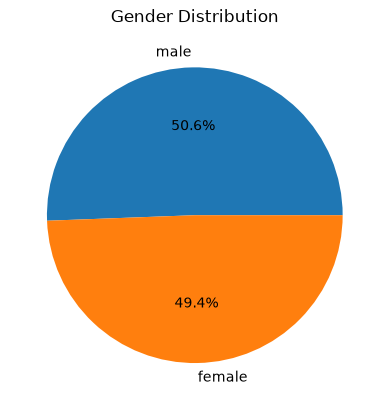

In [38]:
data = df['gender'].value_counts()
plt.pie(data, labels=data.index, autopct='%0.1f%%')
plt.title('Gender Distribution')
plt.show()

In [39]:
df['gender'].isna().sum()

np.int64(0)

**Conclusion:**
- The gender data is almost equally distributed.
- There is no missing data in this col

**`2. diabetic:`**

In [40]:
df['diabetic'].value_counts()

diabetic
non-diabetic    698
diabetic        642
Name: count, dtype: int64

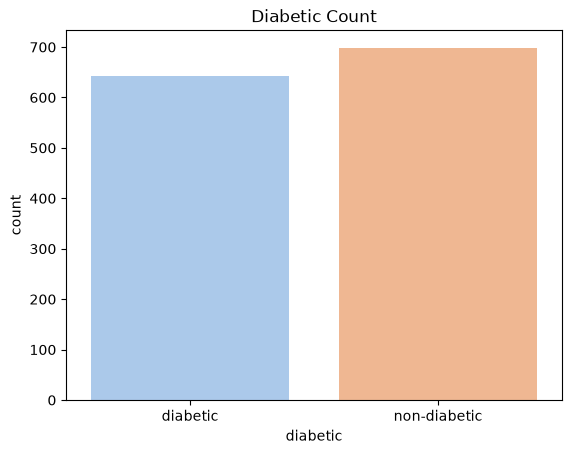

In [41]:
sns.countplot(data=df, x='diabetic', hue='diabetic', palette='pastel')
plt.title('Diabetic Count')
plt.show()

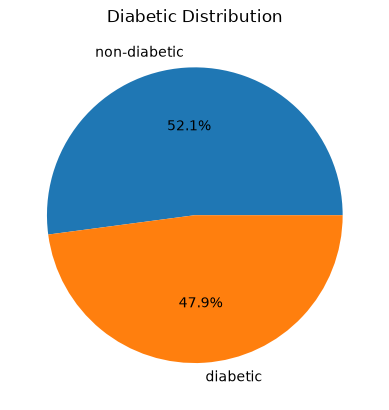

In [42]:
data = df['diabetic'].value_counts()
plt.pie(data, labels=data.index, autopct='%0.1f%%')
plt.title('Diabetic Distribution')
plt.show()

**Conclusion:**
- The dataset maintains a nearly balanced split with 52.1% non-diabetic and 47.9% diabetic policyholders.
- Almost half the sample has diabetes, making this a crucial health variable for predicting insurance claim costs.

**`3. smoker:`**

In [43]:
df['smoker'].value_counts()

smoker
non-smoker    1066
smoker         274
Name: count, dtype: int64

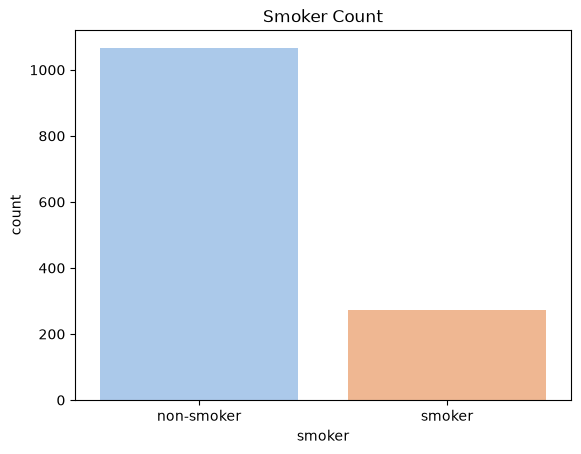

In [44]:
sns.countplot(data=df, x='smoker', hue='smoker', palette='pastel')
plt.title('Smoker Count')
plt.show()

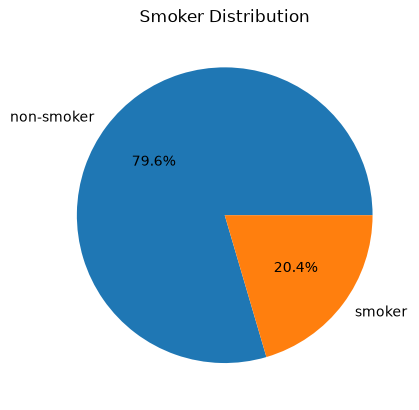

In [45]:
data = df['smoker'].value_counts()
plt.pie(data, labels=data.index, autopct='%0.1f%%')
plt.title('Smoker Distribution')
plt.show()

**Conclusion:**
- The dataset is heavily imbalanced, with non-smokers making up 79.6% (1,066) of entries and smokers accounting for only 20.4% (274).
- Although a minority group, smokers typically drive disproportionately high insurance claim costs in health datasets.

**`4. region:`**

In [46]:
df['region'].value_counts()

region
southeast    446
northwest    349
southwest    314
northeast    231
Name: count, dtype: int64

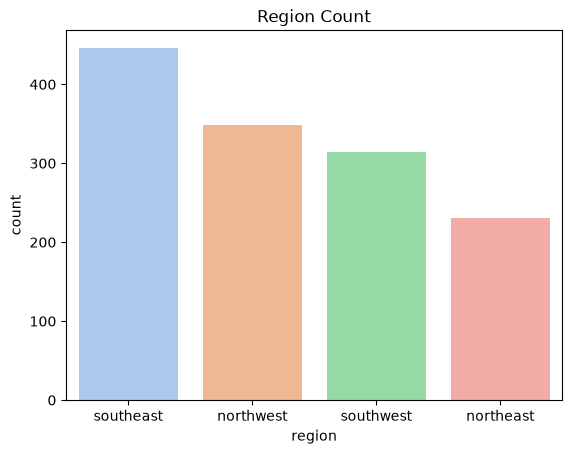

In [47]:
sns.countplot(data=df, x='region', hue='region', palette='pastel')
plt.title('Region Count')
plt.show()

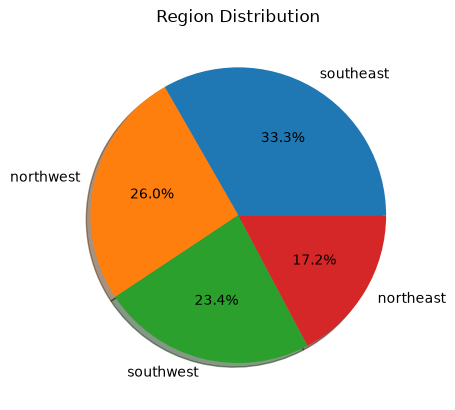

In [48]:
data = df['region'].value_counts()
plt.pie(data, labels=data.index, autopct='%0.1f%%', shadow=True)
plt.title('Region Distribution')
plt.show()

**Conclusion:**
- The southeast region has the highest representation at 33.3% (446), while the northeast has the lowest at 17.2% (231).

## `Bivariate Analysis:`

> Our target col is claim so we will do bivariate analysis of claim col with rest of the col to find the relations on the basis of which the claim price is affected

**`1. claim and age:`**

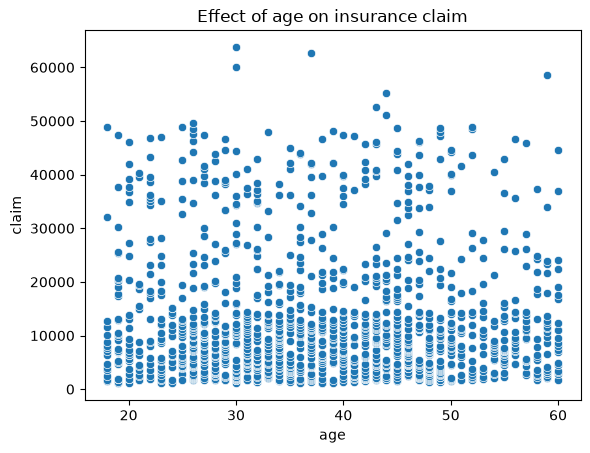

In [71]:
sns.scatterplot(data=df, x='age', y='claim')
plt.title('Effect of age on insurance claim')
plt.show()

- There is no clear visual linear realtionship between age and claim of insurance.
- Claims show high variability across all age groups.
- A few observations have exceptionally high claim amounts compared with the majority of thr data.
- No obvious groups clusters are visible.
The scatter plot does not provide some useful information so we should check it with other cols for getting useful results.

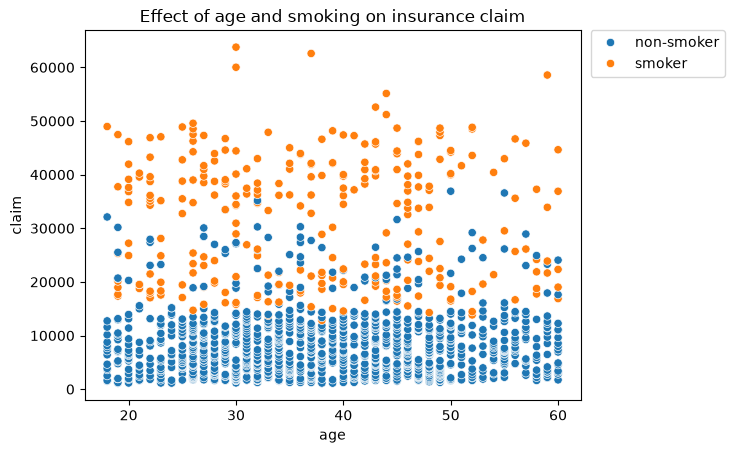

In [49]:
sns.scatterplot(data=df, x='age', y='claim', hue='smoker')
plt.title('Effect of age and smoking on insurance claim')
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

- The scatter plot suggests that age alone has only a weak relationship with insurance claims. However, when smoking status is included, smokers consistently exhibit much higher claim amounts than non-smokers across almost all age groups. This indicates that smoking has a stronger association with insurance claims than age.

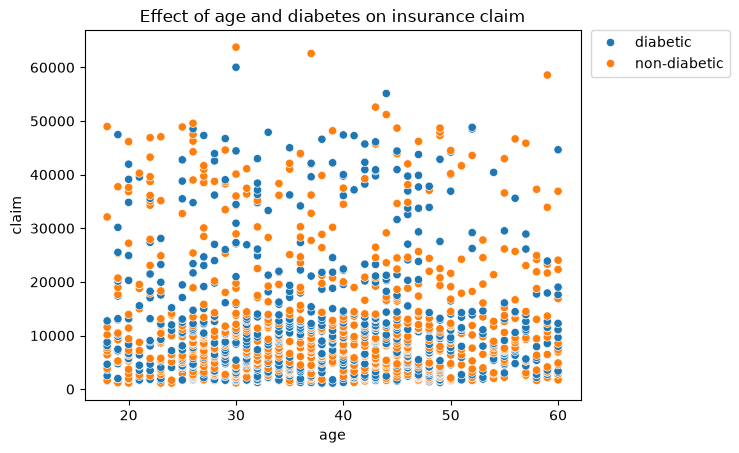

In [50]:
sns.scatterplot(data=df, x='age', y='claim', hue='diabetic')
plt.title('Effect of age and diabetes on insurance claim')
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

- The plot reveals that there is no significant correlation between claim value and prevalence of diabetes

In [52]:
df['age'].corr(df['claim'])

np.float64(-0.027829894243012736)

- This shows there is a very weak relationship between age and claim so alone with age we can to tell the trend of claim.

**`2. claim and bmi:`**

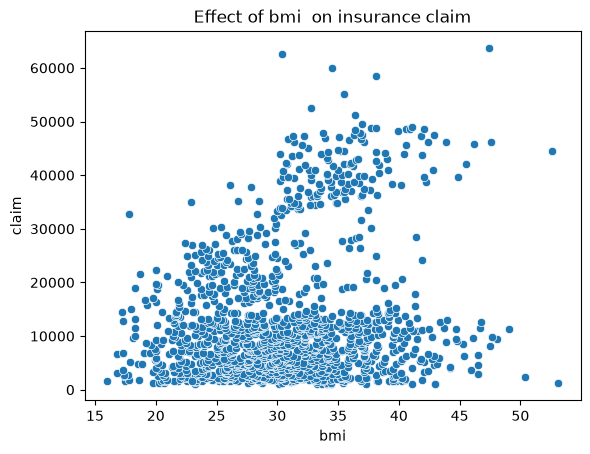

In [53]:
sns.scatterplot(data=df, x='bmi', y='claim')
plt.title('Effect of bmi  on insurance claim')
plt.show()

- The scatter plot does not show a clear visual relationship with bmi there are various clusters as visible in the plot.

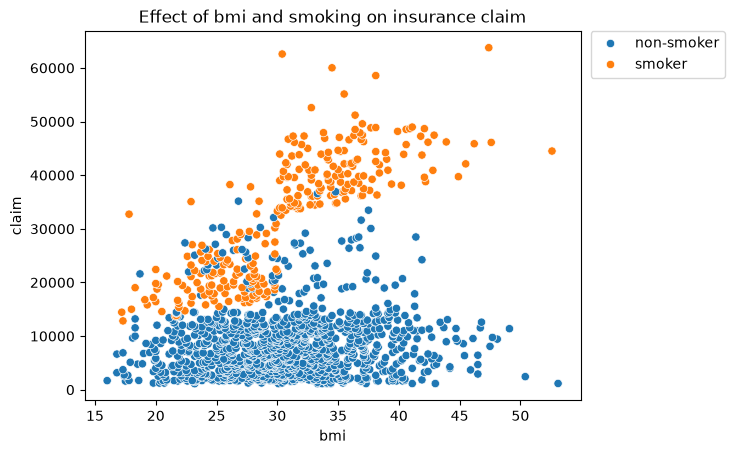

In [54]:
sns.scatterplot(data=df, x='bmi', y='claim', hue='smoker')
plt.title('Effect of bmi and smoking on insurance claim')
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

- The plot reveals that only bmi can not explain the reason for the high insurance claim. By adding an external feature of smoker we can clearly se that most of the high claims were done by the patients who are smoker. This gives us clear indication that smoking is one of the most valuable factor affecting insurance claim.

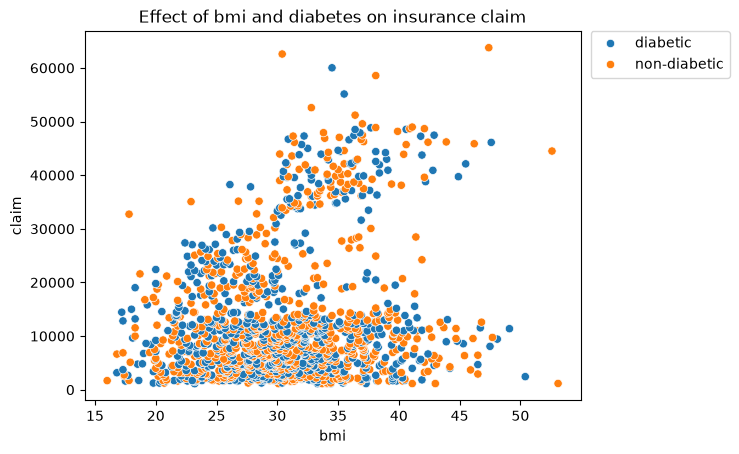

In [55]:
sns.scatterplot(data=df, x='bmi', y='claim', hue='diabetic')
plt.title('Effect of bmi and diabetes on insurance claim')
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

- By observing the scatter plot we can conclude that there is no such visual linear relation between bmi and claim when external factor of diabetes is included. It shows the cluster of at various points in which both diabetic category is involved.

In [57]:
df['bmi'].corr(df['claim'])

np.float64(0.19740133652071148)

- The correlation is almost 0.2 which shows a weak positive correlatio between bmi and claim so bmi is also not the main factor affecting claim.

**`3. claim and bloodpressure:`**

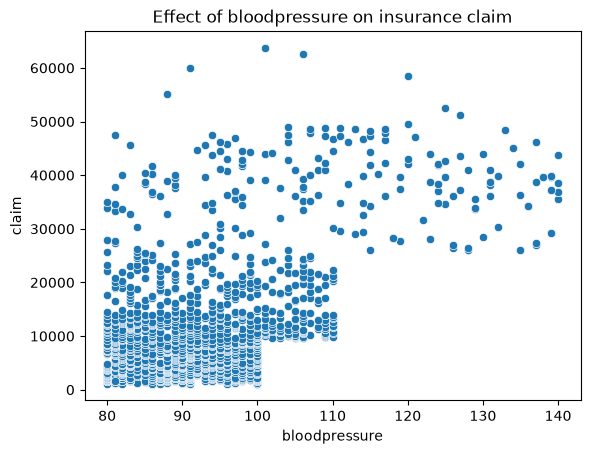

In [58]:
sns.scatterplot(data=df, x='bloodpressure', y='claim')
plt.title('Effect of bloodpressure on insurance claim')
plt.show()

- The plot shows that as bp grow there are no lower claims this mean there is some sort of linear realtion between bp and claim.
- As the bp grows above normal claims are higher while for normal bp the claims vary from low to high giving no clear meaning.
- Some claims are exceptionally high.

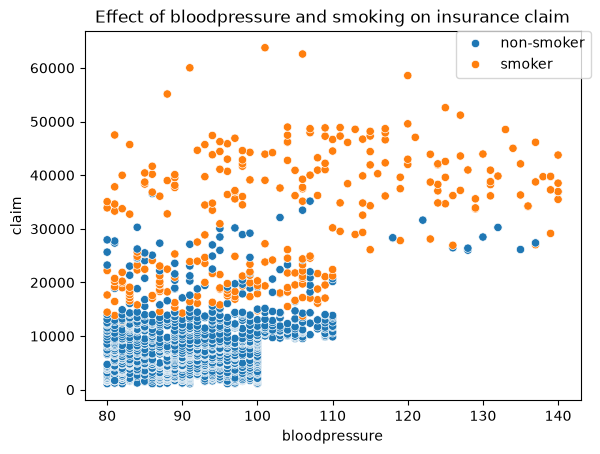

In [59]:
sns.scatterplot(data=df, x='bloodpressure', y='claim', hue='smoker')
plt.title('Effect of bloodpressure and smoking on insurance claim')
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

- Again we can clearly see that most patient who claim higher are smoker and one interesting fact that most of non smoker have normal bp while smokers have got higher bp. This again proves that we need smoking category to identify why patients have made high insurance claim.

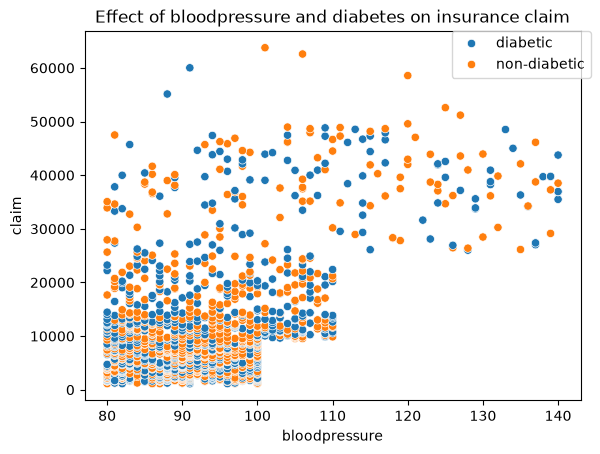

In [60]:
sns.scatterplot(data=df, x='bloodpressure', y='claim', hue='diabetic')
plt.title('Effect of bloodpressure and diabetes on insurance claim')
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

- There is no such valuable result when factor of diabetes was added this mean diabetes have no much effect on insurance claim.

In [62]:
df['bloodpressure'].corr(df['claim'])

np.float64(0.5313409750663161)

- This shows there is moderate amount of correlation between bloodpressure and claim. 

**`4. claim and children:`**

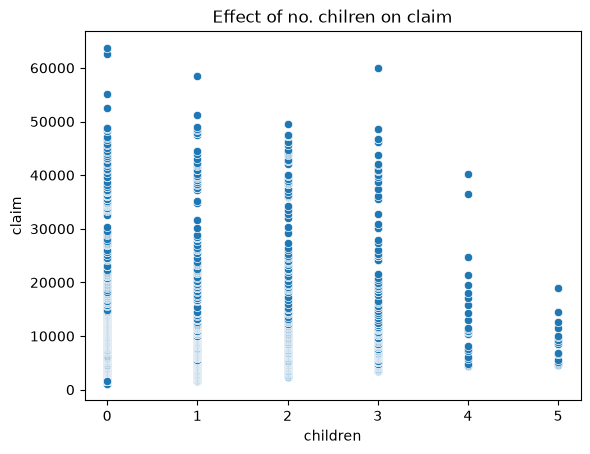

In [64]:
sns.scatterplot(data=df, x='children', y='claim')
plt.title('Effect of no. chilren on claim')
plt.show()

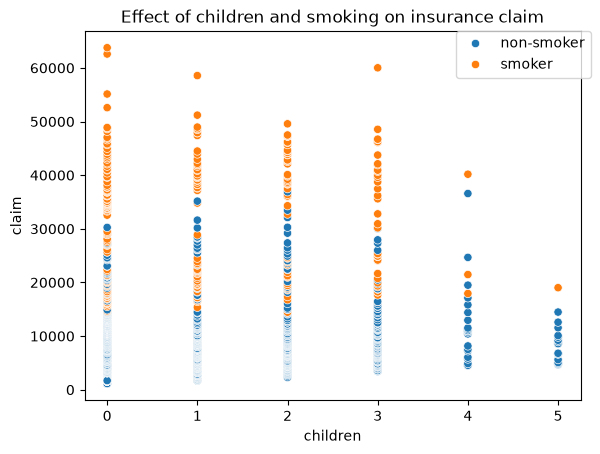

In [66]:
sns.scatterplot(data=df, x='children', y='claim', hue='smoker')
plt.title('Effect of children and smoking on insurance claim')
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

- This shows the smoker patient have raised high claim for insurance.

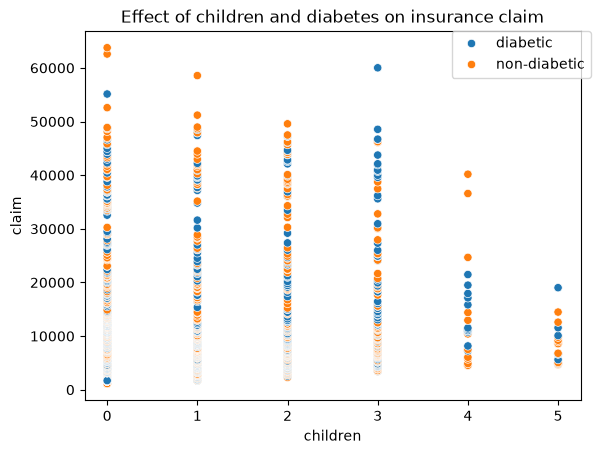

In [65]:
sns.scatterplot(data=df, x='children', y='claim', hue='diabetic')
plt.title('Effect of children and diabetes on insurance claim')
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

- All plots show no such strong relation between children and claim so we can conclude that children numbers have no effect on how much one is going to claim.

In [67]:
df['children'].corr(df['claim'])

np.float64(0.06923287824477578)

- This shows a very weak correaltion.

**`5. claim and gender:`**

In [94]:
df.groupby('gender')['claim'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,662.0,12569.578897,11128.703817,1607.51,4885.1625,9412.965,14454.6900,63770.43
male,678.0,13919.790457,12969.700466,1121.87,4523.1875,9333.015,18970.1675,62592.87


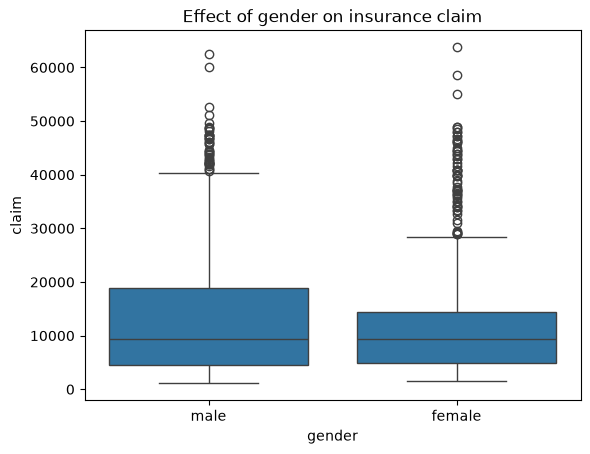

In [95]:
sns.boxplot(data=df, x='gender', y='claim')
plt.title('Effect of gender on insurance claim')
plt.show()

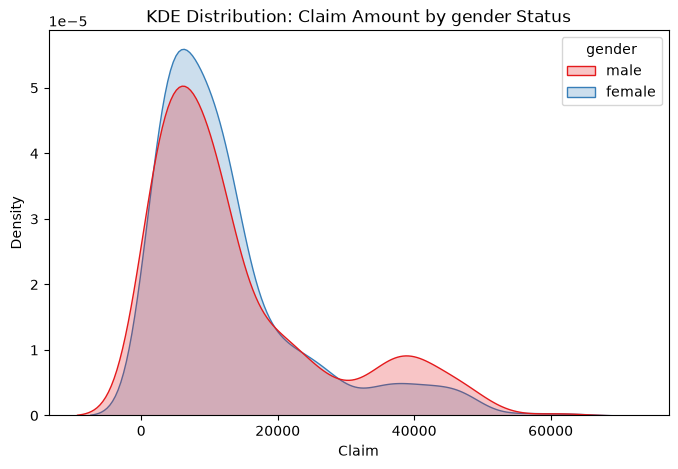

In [98]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='claim', hue='gender', fill=True, common_norm=False, palette='Set1')
plt.title('KDE Distribution: Claim Amount by gender Status')
plt.xlabel('Claim')
plt.show()

- Median claim amounts are almost identical across genders (~$9.4k for male vs ~$9.3k for female), showing no gender bias for baseline medical claims.
- Males display a slightly higher mean (~$13.9k vs ~$12.6k) and a larger upper whisker reach due to a higher concentration of extreme claim values.
- The KDE plot shows a more pronounced peak near $40,000 for males, indicating gender interacts with underlying risk factors like smoking or BMI.

**`6. claim and diabetic:`**

In [90]:
df.groupby('diabetic')['claim'].describe()

,count,mean,std,min,25%,50%,75%,max
diabetic,,,,,,,,
diabetic,642.0,13142.624346,11935.356153,1121.87,4563.1775,9421.97,16107.7575,60021.40
non-diabetic,698.0,13354.031991,12275.376160,1131.51,4891.1875,9274.18,16862.7925,63770.43


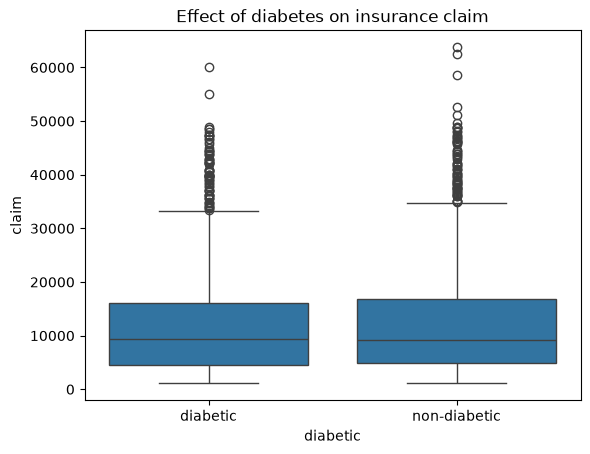

In [91]:
sns.boxplot(data=df, x='diabetic', y='claim')
plt.title('Effect of diabetes on insurance claim')
plt.show()

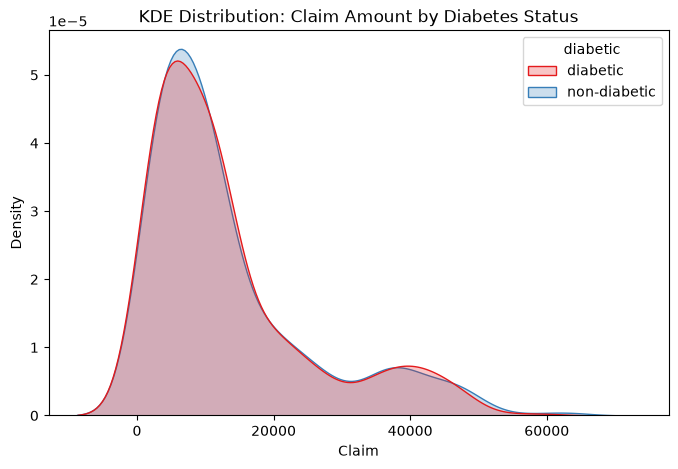

In [96]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='claim', hue='diabetic', fill=True, common_norm=False, palette='Set1')
plt.title('KDE Distribution: Claim Amount by Diabetes Status')
plt.xlabel('Claim')
plt.show()

- Diabetes status on its own shows no significant difference in median insurance claims (~$9,422 for diabetic vs ~$9,274 for non-diabetic).
- The KDE plot shows near-perfect overlap between both categories across all claim tiers, including high-value claims.
- This shows there is no such diffenrece made by diabetes on insurance claim.



**`7. claim and smoker:`**

In [83]:
df.groupby('smoker')['claim'].describe()

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
non-smoker,1066.0,8421.121576,5995.843246,1121.87,3975.185,7341.415,11361.235,36910.61
smoker,274.0,32050.231971,11541.547338,12829.46,20826.245,34456.350,41019.205,63770.43


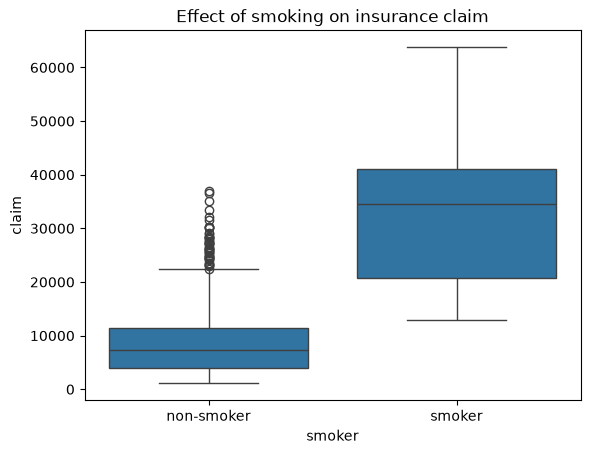

In [73]:
sns.boxplot(data=df, x='smoker', y='claim')
plt.title('Effect of smoking on insurance claim')
plt.show()

- Smokers have a substantially higher median claim amount (~$35,000) compared to non-smokers (~$7,500).
- Non-smoker claims are low and tightly clustered with high-end outliers, whereas smoker claims exhibit high overall variance up to ~$63,000.
- Smoking status acts as a strong categorical separator for predicting target claim values in model training.

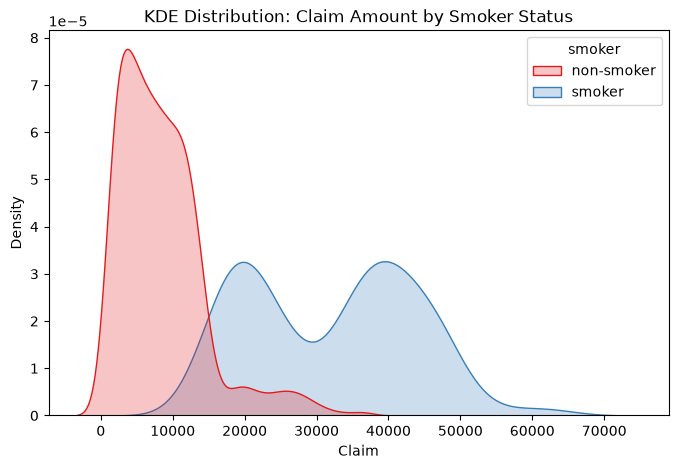

In [89]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='claim', hue='smoker', fill=True, common_norm=False, palette='Set1')
plt.title('KDE Distribution: Claim Amount by Smoker Status')
plt.xlabel('Claim')
plt.show()

- From the plot we can clearly see that for smoker there are two humps its a bimodal kde the curve shows the smokers split into two distinct sub-peaks suggesting smoking interacts with another variable.
- Non-smokers heavily concentrate below $15,000, confirming that smoker status clearly separates low-cost vs high-cost claims.

**`8. claim and region:`**

In [99]:
df.groupby('region')['claim'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,231.0,16889.044719,11578.101476,1694.80,9521.1350,13129.600,21715.6350,58571.07
northwest,349.0,11672.088453,11031.744657,1136.40,4032.2400,8116.270,14254.6100,60021.40
southeast,446.0,12979.121502,13168.035426,1121.87,4362.8150,7335.390,16929.1300,63770.43
southwest,314.0,12723.129841,11578.518764,1261.44,5029.3775,9123.185,13839.0825,52590.83


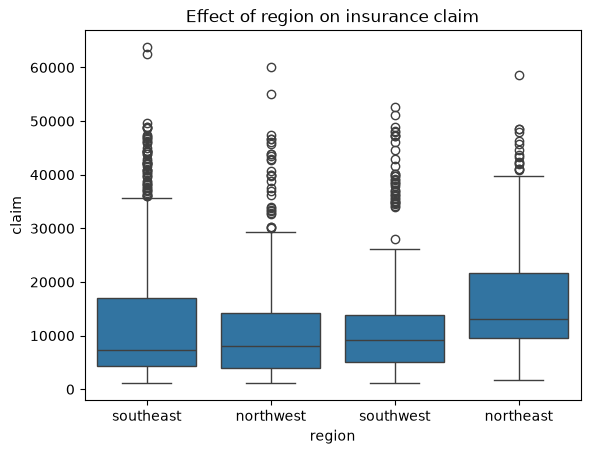

In [109]:
sns.boxplot(data=df, x='region', y='claim')
plt.title('Effect of region on insurance claim')
plt.show()

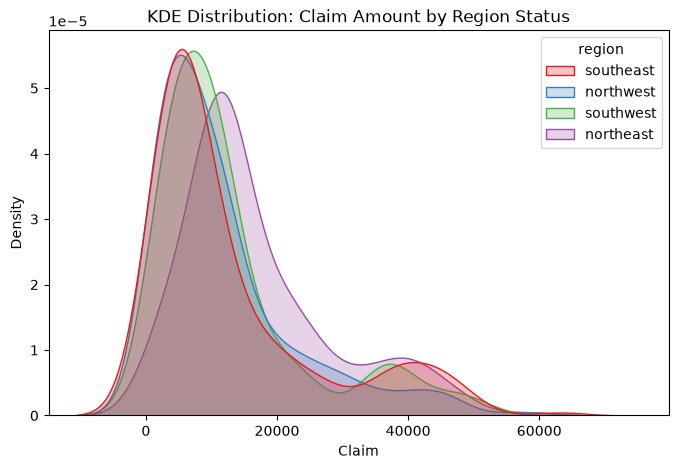

In [112]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='claim', hue='region', fill=True, common_norm=False, palette='Set1')
plt.title('KDE Distribution: Claim Amount by Region Status')
plt.xlabel('Claim')
plt.show()

- The northeast region consistently commands higher baseline claim amounts, with its median (~$13.1k) and 25th percentile (~$9.5k) noticeably higher than all other regions.
- While southeast has a lower median, it exhibits the highest concentration of extreme outliers ($40k+), driving up its overall standard deviation and mean.
- northwest, southwest, and southeast share similar primary claim peaks (~$5,000–$7,000), making northeast the primary outlier among geographic locations.

## `Key Findings:`

After performing univariate and bivariate exploratory data analysis on the insurance dataset, the following insights were obtained:
- Smoking status is the strongest factor associated with insurance claim amounts. Smokers consistently have significantly higher insurance claims than non-smokers across almost all age groups, making smoking the most influential feature in this dataset.

- Age, BMI, and Blood Pressure show weak to moderate positive relationships with insurance claims. While claim amounts tend to increase slightly with these variables, the relationships are not as strong as smoking.
- Diabetes, Gender, and Number of Children do not show a strong association with insurance claim amounts. The distributions of claims across these categories are relatively similar.

- Region shows some variation in insurance claims. The Southeast region has the highest average insurance claim, while the remaining regions have comparatively lower claim amounts. However, regional differences are much smaller than the impact of smoking.